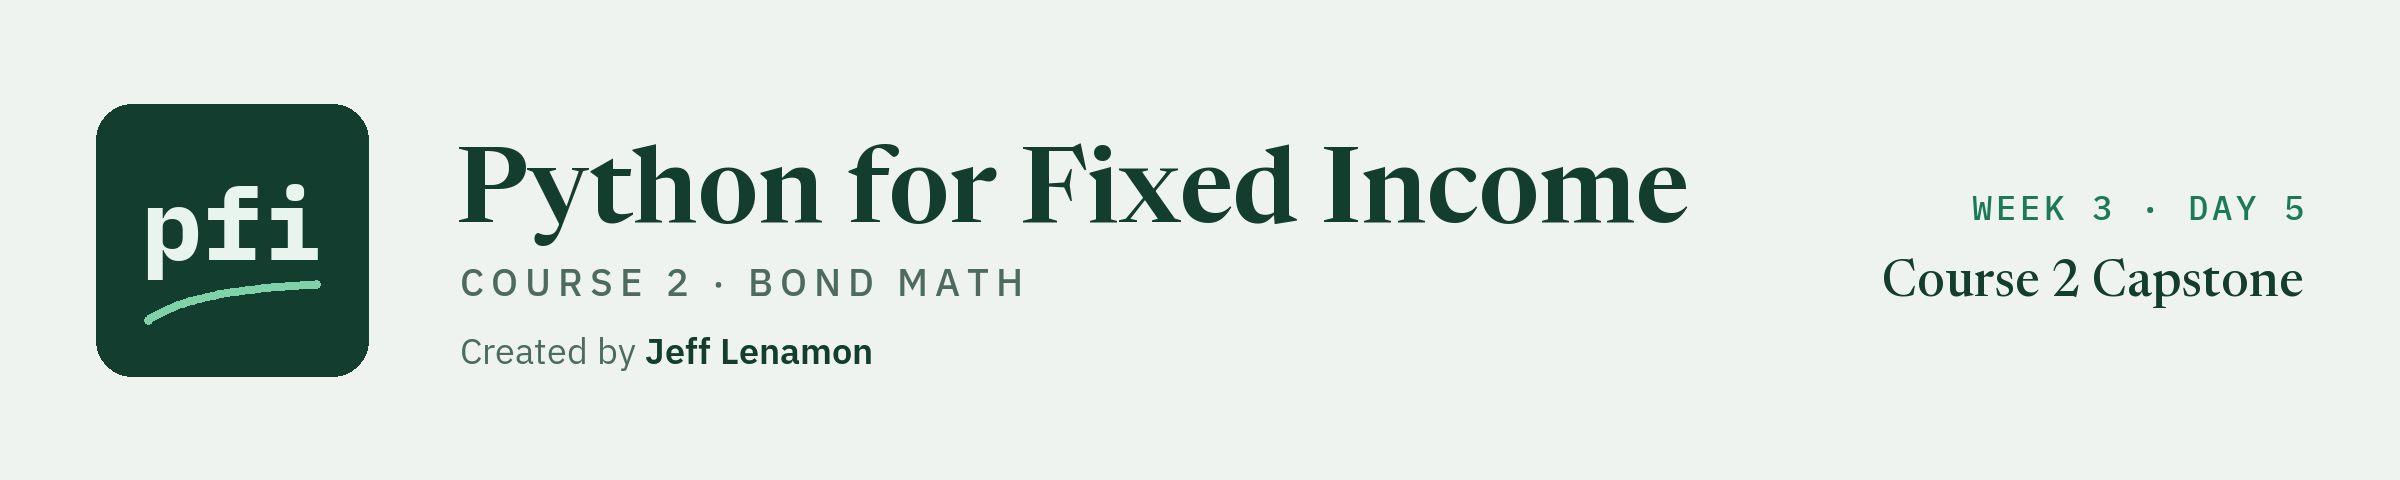

# Course 2 Capstone

Week 3, Day 5. A month-end extract tested against its cover note, cleaned and recomputed with your own bondmath, reconciled to the cent, turned into a risk report in Excel, rerun on September, kept in Git, and written up for the portfolio manager. You write the code.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week3/day5/course2_capstone.ipynb)

## The Brief

### The scenario

It is month end on the credit desk, and you are the analyst. Operations has sent the holdings extract for 2026-11-30 with a cover note. The portfolio manager wants three things before the month-end meeting: a book whose every number you have recomputed yourself, a risk report in Excel, and a page that says what the book's risk is and what was wrong with the file.

Fourteen days built the tools: your own `bondmath.py`, tested against Excel, and Git to keep it safe. Today you use all of them on one job, the way Course 1 ended with its project. The extract carries bond-math problems, planted on purpose, and nothing in this notebook says what they are. The desk's rules and your module find them.

Everything in the files is invented: the issuers, the tickers, the CUSIPs, the prices, and the positions. No name refers to a real company.

### What to hand in

This notebook, completed and run from top to bottom, with eight deliverables:

| # | Deliverable | Where |
| --- | --- | --- |
| 1 | `bondmath.py` complete, and `python -m pytest -q` passing with its output saved | Section 1 |
| 2 | `clean_book(raw, benchmark, curve)` in `capstone.py`, with `assert` checks, recomputing price, accrued, yield, modified duration, DV01, convexity, spread to the curve, spread duration, and DTS for every bond with `bondmath` | Sections 2 to 5 |
| 3 | A reconciliation: recomputed against delivered, column by column, every difference above tolerance explained, and the control totals matched to the cent | Section 6 |
| 4 | `risk_report(book, ratings)` in `capstone.py`, written to `course2_risk_report.xlsx` with three sheets and read back | Section 7 |
| 5 | The same `risk_report` run on the September book, with September and November side by side | Section 8 |
| 6 | One Git commit for each deliverable in the work folder, and `git log --oneline` | Every section, then Save the Day with Git |
| 7 | An AI-use log | Section 9 |
| 8 | A written description of the book's risk and of the data problems found | Section 9 |

### How long

The course map gives the capstone one day. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 the module, 2 testing the extract, 3 fixing the inputs |
| Second | 4 repricing every bond, 5 `clean_book`, 6 the reconciliation |
| Third | 7 the risk report, 8 September and November, 9 the log and the description, then Git and Bring It Home |

### The rules

1. **Work in a copy.** `raw` is the file as it arrived and is never changed. Question 2.1 makes the working copy, `book`.
2. **State every decision.** Before each fix, add a markdown cell that says what you are changing, in how many rows, and the evidence.
3. **Print the headline numbers before and after every fix.** The setup gives you `headline()`.
4. **Every analytic comes from your module,** on the book's conventions: settlement on the as-of date, semiannual coupons, US 30/360.
5. **Describe, never recommend.** Every sentence you write says what the data shows. Nothing recommends, ranks, or forecasts a bond, an issuer, or a sector. A scenario is a mechanical what-if, never a forecast.
6. **Git only in the work folder.** Every Git command is written `!git -C "{work}" ...`, as on every day of the course.
7. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

Every earlier notebook of the course and your notes; the documentation of pandas and openpyxl; and an AI assistant, used the way the course taught: the docstring is the prompt, read the code that comes back, test it against Excel's numbers or a control total, and keep a log as you go (question 9.1). Nothing from an employer goes into an AI tool or into Colab. The course data is synthetic for that reason.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_2_1`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. The right answers are not written anywhere in this notebook: each check holds a short code made from the right answer, and `check()` makes a code from yours in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the places the question states before it is compared, so give at least that many. Text is compared without regard to capitals or spaces at the ends.

Your decisions change the numbers that follow. After section 4 and again after `clean_book`, a checkpoint cell tests your book against the cover note and against the decisions the worked version made. Do not go on until it passes. Under some questions a closed block that starts "Stuck after trying?" holds the decision the checkpoint expects for one kind of problem. Leave it closed until you have made your own.

Worked answers are in `course2_capstone_solutions.ipynb` in this folder. Open it after you have written your own description.

## The Data

Five files, all in the repo's `data` folder. Units: **`coupon` and `yield_pct` in percent, `oas` in basis points, `duration` and `spread_duration` in years, `dts` in years times basis points, `price` and `accrued` per 100 of face, and `par_held`, `amount_outstanding`, and `market_value` in dollars.**

| File | What it is |
| --- | --- |
| `course2_capstone_holdings.csv` | the extract: one row should be one bond the desk holds, as of 2026-11-30. The same 19 columns as Course 1's extracts, so Course 1 code runs on it |
| `course2_capstone_cover_note.txt` | the operations team's note, with the control totals and the conventions |
| `benchmark.csv` | the benchmark of 821 bonds, as of 2026-09-30, the same columns with `weight_pct` instead of `par_held` |
| `course2_treasury_curve.csv` | the desk's curve file: the invented curve the holdings were built on, at 10 tenors (day 11) |
| `ratings.csv` | the rating scale: `rating`, `score`, `bucket`, `grade` |
| `holdings.csv` | the September book, as of 2026-09-30, clean (days 7 to 14) |

The columns of the extract, as Course 1 described them: `duration` is **modified** duration; `spread_duration` equals it for these bullets; `dts` is spread duration times `oas`, to 1 decimal; `oas` is the spread to the invented curve at the bond's own maturity (day 12); `market_value` is face held times (price plus accrued), divided by 100.

## Setup

Run the setup cells first. They are complete: do not change them. The first makes today's work folder and copies the two Excel reference files into it. The next two write the complete `bondmath.py` and `test_bondmath.py`, the reference version as day 14 left them: 25 functions and 40 tests. **If you kept your own `my_bondmath` up to date, paste your own two files into those cells instead.** The capstone runs on either. Then the module is imported, and the last setup cell loads the files and defines `headline()`, `answer_text()`, and `check()`.

Q. Set up the work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_15_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_15_raf834b3, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]


def test_convexity_matches_excel_finite_difference():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
        # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
        result = bondmath.convexity(*bond_inputs(row))
        assert result == pytest.approx(float(row["convexity_fd"]), abs=1e-3), row["case_id"]


# The invented curve the holdings file was built on, at ten tenors: round(3.55 + 1.05 x (1 - exp(-T / 7)), 3)
CURVE_TENORS = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
CURVE_YIELDS_PCT = [3.587, 3.622, 3.69, 3.811, 3.916, 4.086, 4.214, 4.348, 4.54, 4.586]


def test_on_a_tenor_returns_its_yield():
    for tenor, yield_pct in zip(CURVE_TENORS, CURVE_YIELDS_PCT):
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(yield_pct, abs=1e-12)


def test_matches_numpy_interp():
    import numpy as np  # numpy is in the course requirements; bondmath itself does not use it

    for tenor in (0.1, 0.92, 1.5, 4.0, 6.4, 8.75, 15.0, 29.9, 35.0):
        expected = float(np.interp(tenor, CURVE_TENORS, CURVE_YIELDS_PCT))
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(expected, abs=1e-12)


def test_flat_beyond_the_ends():
    # below the first tenor: the first yield; above the last: the last yield
    assert bondmath.interpolate_yield(0.1, CURVE_TENORS, CURVE_YIELDS_PCT) == 3.587
    assert bondmath.interpolate_yield(40, CURVE_TENORS, CURVE_YIELDS_PCT) == 4.586


def test_raises_when_tenors_not_ascending():
    with pytest.raises(ValueError):
        bondmath.interpolate_yield(4, [1, 3, 2], [3.7, 3.9, 3.8])


def test_years_to_maturity_cases():
    # (settlement, maturity, 30/360 days); each was checked in Excel as YEARFRAC(settlement, maturity, 0) x 360
    cases = [
        (date(2026, 9, 30), date(2036, 9, 30), 3600),  # exactly ten years
        (date(2026, 9, 30), date(2032, 6, 18), 2058),  # the first bond in holdings.csv
        (date(2027, 2, 28), date(2031, 8, 31), 1621),  # the 31st end stays 31 after a 28 February start
    ]
    for settlement, maturity, days in cases:
        assert bondmath.years_to_maturity(settlement, maturity) == pytest.approx(days / 360, abs=1e-12)


def test_spread_to_curve_known_case():
    # a 5 percent yield at 6 years: halfway between the 5-year (4.086) and 7-year (4.214) points
    curve_at_6_years = 4.086 + (4.214 - 4.086) * (6 - 5) / (7 - 5)
    expected_bp = (5.0 - curve_at_6_years) * 100
    result = bondmath.spread_to_curve_bp(5.0, 6.0, CURVE_TENORS, CURVE_YIELDS_PCT)
    assert result == pytest.approx(expected_bp, abs=1e-9)


def test_spread_reproduces_oas_rows():
    # five rows of holdings.csv (as of 2026-09-30): cusip, maturity, yield_pct, oas
    rows = [
        ("99080CAE8", date(2032, 6, 18), 5.606, 147),
        ("99049XAE2", date(2029, 4, 17), 9.22, 535),
        ("99039NAC0", date(2030, 6, 3), 5.509, 153),
        ("99039NAG1", date(2053, 4, 9), 6.756, 218),
        ("99034IAD4", date(2036, 4, 5), 5.6, 127),
    ]
    for cusip, maturity, yield_pct, oas in rows:
        years = bondmath.years_to_maturity(date(2026, 9, 30), maturity)
        # the file was built on the curve's formula at the bond's own maturity, rounded to 3 decimals,
        # so a one-point curve at exactly that maturity gives the file's spread
        curve_yield_pct = round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)
        result = bondmath.spread_to_curve_bp(yield_pct, years, [years], [curve_yield_pct])
        assert result == pytest.approx(oas, abs=1e-9), cusip


def test_spread_duration_equals_modified_duration():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # for a bullet priced at curve plus spread, a spread move is a yield move; the 1 bp central
        # difference sits above the exact slope by up to 1.6e-5 years on a 30-year bond
        result = bondmath.spread_duration(*bond_inputs(row))
        assert result == pytest.approx(bondmath.modified_duration(*bond_inputs(row)), abs=5e-5), row["case_id"]


def test_dts_reproduces_file_rows():
    # five rows of holdings.csv: cusip, spread_duration, oas, dts (the file rounds dts to 1 decimal)
    rows = [
        ("99080CAE8", 4.627, 147, 680.2),
        ("99049XAE2", 2.165, 535, 1158.3),
        ("99039NAC0", 3.25, 153, 497.2),
        ("99039NAG1", 12.113, 218, 2640.6),
        ("99034IAD4", 7.338, 127, 931.9),
    ]
    for cusip, spread_duration_years, spread_bp, file_dts in rows:
        assert bondmath.dts(spread_duration_years, spread_bp) == pytest.approx(file_dts, abs=0.05 + 1e-9), cusip


def test_weighted_average_known_case():
    # (4 x 1 + 6 x 1 + 10 x 2) / (1 + 1 + 2) = 30 / 4
    assert bondmath.weighted_average([4.0, 6.0, 10.0], [1, 1, 2]) == pytest.approx(7.5, abs=1e-12)


def test_weighted_average_raises_on_zero_weights():
    with pytest.raises(ValueError):
        bondmath.weighted_average([4.0, 6.0], [0, 0])


def test_estimate_close_to_full_reprice_for_small_shift():
    shift_bp = 5
    for row in REFERENCE:
        if row["group"] != "holdings":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # full reprice: the dirty price after the shift minus the dirty price before
        before = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        after = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct + shift_bp / 100, frequency, basis)
        # the estimate from duration and convexity
        duration_years = bondmath.modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        convexity_years2 = bondmath.convexity(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        estimate = bondmath.price_change_estimate(before, duration_years, convexity_years2, shift_bp)
        assert estimate == pytest.approx(after - before, abs=1e-4), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity', 'macaulay_duration', 'modified_duration', 'dv01', 'convexity', 'interpolate_yield', 'years_to_maturity', 'spread_to_curve_bp', 'spread_duration', 'dts', 'weighted_average', 'price_change_estimate']


Q. Load the capstone's files, read the control totals from the cover note, and define the helpers.

In [5]:
# re finds the control totals in the cover note; hashlib makes the short codes that check() compares
import hashlib
import re
from datetime import date

from IPython.display import Markdown, display

# the capstone's files, from the same place as the reference files: the repo's data folder, or GitHub
raw = pd.read_csv(data_folder + "course2_capstone_holdings.csv")
benchmark = pd.read_csv(data_folder + "benchmark.csv")
ratings = pd.read_csv(data_folder + "ratings.csv")
curve = pd.read_csv(data_folder + "course2_treasury_curve.csv")
september = pd.read_csv(data_folder + "holdings.csv")
if on_github:
    cover_note = urllib.request.urlopen(RAW_DATA + "course2_capstone_cover_note.txt").read().decode("utf-8")
else:
    cover_note = (local_data / "course2_capstone_cover_note.txt").read_text(encoding="utf-8")


def control_total(label):
    """A figure from the cover note, as a number: the text after the label, without its commas."""
    return float(re.search(label + r":\s+([\d,.]+)", cover_note).group(1).replace(",", ""))


# the control totals, read from the note rather than typed
expected_bonds = int(control_total("Number of bonds"))
expected_face = int(control_total("Total face"))
expected_value = control_total("Total market value")


def headline(label, table):
    """The headline numbers of a table, to print before and after every fix."""
    print(label)
    print(f"   rows: {len(table):,}")
    print(f"   face: {table['par_held'].sum():,} dollars")
    print(f"   market value: {table['market_value'].sum():,.2f} dollars")
    print(f"   mean yield: {table['yield_pct'].mean():.3f} percent over {table['yield_pct'].count()} rows")


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # several values: each one in turn
        return ",".join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f"{number:.{places}f}"


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f"{label}: not yet. The answer should be a number, a piece of text, or several of them in a tuple")
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(f"{label}|{text}".encode()).hexdigest()[:12]
    if found == code:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}. Check the rounding the question asks for.")


print(cover_note)
print(f"Loaded raw, benchmark {benchmark.shape}, ratings {ratings.shape}, curve {curve.shape}, september {september.shape}")

To: Credit desk
From: Operations
Subject: Month-end holdings extract, as of 2026-11-30

The month-end extract is attached as course2_capstone_holdings.csv. It is the same layout as last month.

Control totals for the book:
  Number of bonds:      199
  Total face:           493,000,000 dollars
  Total market value:   496,372,835.00 dollars

Market value is face times clean price plus accrued interest, divided by 100.
All positions settle and are priced as of 2026-11-30. Analytics are semiannual, 30/360.
Please tell us if the extract does not agree with these totals.

Loaded raw, benchmark (821, 19), ratings (18, 4), curve (10, 2), september (200, 19)


## 1 Your Complete Module

### 1.1 pytest on the whole module

Q. Run your test file with pytest in the work folder, as every day of the course has, and save the output. Store the number of tests that passed in **answer_1_1**. Every test must pass before you go on: the rest of the capstone stands on the module.

In [6]:
# your code here
answer_1_1 = ...

In [7]:
check('Question 1.1', answer_1_1, '1c7a85d0530a')

Question 1.1: not attempted yet


### 1.2 Deliverable 1, committed

The work folder becomes a repository in the next two cells: the install check, `init`, the local settings, and the guard that stops the notebook unless Git is working in the work folder and nowhere else. They are complete.

Q. Write a `.gitignore` that keeps `__pycache__/` and `.pytest_cache/` out (day 6), then commit `.gitignore`, the module, its tests, and the two reference files they read, with a message that names the deliverable. Show the history.

In [8]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [9]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_15_raf834b3 and nowhere else


In [10]:
# your .gitignore here, with %%writefile

In [11]:
# your Git commands here, each one written  !git -C "{work}" ...

## 2 Test the Extract

There is no list of what is wrong with this file. There is the cover note, and there are the rules the desk expects every extract to meet. **The brief: test the extract against its cover note and the rules below. Section 2 is for finding: count on `book` as received, and fix nothing yet.** A rule that every row passes is a result too, and it goes in your description.

| Rule | What the desk expects of an extract |
| --- | --- |
| 1 | One row for each bond held. No row is a copy of another |
| 2 | The maturity is after the as-of date |
| 3 | No number is missing |
| 4 | Units are the data dictionary's: coupon and yield in percent, price and accrued per 100 of face |
| 5 | Market value equals face times (price plus accrued), divided by 100, to the cent |
| 6 | Every analytic column reproduces from the bond's terms with `bondmath`, on the book's conventions, within the course's tolerances |
| 7 | Identifiers, ratings, and sizes are well formed |

Rule 6 is the bond-math rule, and section 4 tests it column by column.

### 2.1 Rows and columns, and a working copy

Q. How many rows and columns does the extract have? Store the shape, a pair (rows, columns), in **answer_2_1**. Then make the working copy: `book`, a copy of `raw`. From here on every fix is made to `book`.

In [12]:
# your code here
book = ...
answer_2_1 = ...

In [13]:
check('Question 2.1', answer_2_1, '4c48b84f8533')

Question 2.1: not attempted yet


### 2.2 The file against the cover note

Q. Print the headline numbers of the extract as received, then the differences from the cover note, file less note, for rows, face, and market value. Store the difference in face, in dollars, in **answer_2_2**.

In [14]:
# your code here
answer_2_2 = ...

In [15]:
check('Question 2.2', answer_2_2, 'ed492beae360')

Question 2.2: not attempted yet


### 2.3 Rule 1: one row for each bond

Q. How many rows of `book` are an exact copy of an earlier row? Store the count in **answer_2_3**, show each copy beside the row it repeats, and print the face and market value the copies carry.

In [16]:
# your code here
answer_2_3 = ...

In [17]:
check('Question 2.3', answer_2_3, '3424bc0c1e6c')

Question 2.3: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

Remove exact duplicate rows, keeping the first of each, and renumber the rows.

</details>

### 2.4 Rule 2: the maturity

Q. How many rows of `book` have a maturity on or before the as-of date? Dates written year-month-day compare correctly as text, and `pd.to_datetime(..., format="%Y-%m-%d")` confirms that every value is a real date. Store the count in **answer_2_4**, and show the rows with their coupon, maturity, and duration.

In [18]:
# your code here
answer_2_4 = ...

In [19]:
check('Question 2.4', answer_2_4, 'a5dd6eb89a7f')

Question 2.4: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A maturity that is not after the as-of date is replaced with the maturity of the same CUSIP in `benchmark.csv`, after checking that the ticker of that CUSIP agrees in the two files.

</details>

### 2.5 Rule 3: missing numbers

Q. How many cells of `book` are missing, over all columns? Store the count in **answer_2_5**, and show the rows that have one. For each, say which of the bond's other numbers could give the missing one back with your module.

In [20]:
# your code here
answer_2_5 = ...

In [21]:
check('Question 2.5', answer_2_5, 'a8df8afb958a')

Question 2.5: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

No row is dropped for a missing price or yield. A blank yield is solved from the row's price with `yield_to_maturity`, and a blank price from the row's yield with `price`, each on the book's conventions and rounded to 3 decimals like the rest of the column.

</details>

### 2.6 Rule 4: units

Q. Summarize `coupon` and `yield_pct`: minimum, quartiles, and maximum. A corporate bond with a coupon or a yield below 1 percent would stand far from every other row of this book. Count the coupons below 1 in **answer_2_6a** and the yields below 1 in **answer_2_6b**, and show those rows with their price and accrued.

In [22]:
# your code here
answer_2_6a = ...
answer_2_6b = ...

In [23]:
check('Question 2.6 coupons', answer_2_6a, 'ab9c114fffc4')
check('Question 2.6 yields', answer_2_6b, '430071243b5d')

Question 2.6 coupons: not attempted yet
Question 2.6 yields: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A coupon or a yield below 1 percent was entered as a decimal. Multiply it by 100 and round to 3 decimals, then confirm in section 4 that the row reprices.

</details>

### 2.7 Rule 5: does the file agree with itself?

Q. Work out face times (price plus accrued), divided by 100, for every row and compare it with `market_value`. Store the number of rows where the two differ by more than half a cent in **answer_2_7**. A row with a blank price cannot be tested yet: say how many rows were tested.

In [24]:
# your code here
answer_2_7 = ...

In [25]:
check('Question 2.7', answer_2_7, '2317ddd23f25')

Question 2.7: not attempted yet


### 2.8 The cover note's other claims, and rule 7

Q. The cover note says every position settles and is priced as of the as-of date. Count the rows whose `price_date` is not the `as_of_date`. Then test rule 7: a CUSIP of nine capital letters or digits, a rating on the scale, a face held above zero and not above the amount outstanding, a spread duration above zero. Store the total number of breaks over all of these tests in **answer_2_8**.

In [26]:
# your code here
answer_2_8 = ...

In [27]:
check('Question 2.8', answer_2_8, '3e40c63367f1')

Question 2.8: not attempted yet


## 3 Fix the Inputs

Section 4 reprices every bond, and a reprice needs sound inputs: one row per bond, a maturity after settlement, a coupon and a yield in percent, and a price and a yield in every row. Fix those first, one decision at a time. For each fix, a markdown cell with the decision and the evidence, then the headline numbers before and after.

### 3.1 Remove the copies

Q. Apply your decision on the copies to `book`. Print the headline numbers before and after, and the face less the cover note. Store the face of `book` after the fix in **answer_3_1**.

In [28]:
# your code here
answer_3_1 = ...

In [29]:
check('Question 3.1', answer_3_1, '855d524c8c2d')

Question 3.1: not attempted yet


### 3.2 The maturity

Q. Find the matured row's CUSIP in `benchmark.csv` and compare the two rows. Apply your decision. Store the maturity the row has after the fix, as text year-month-day, in **answer_3_2**.

In [30]:
# your code here
answer_3_2 = ...

In [31]:
check('Question 3.2', answer_3_2, '5999e2ad76fe')

Question 3.2: not attempted yet


### 3.3 Coupons and yields in percent

Q. Apply your decision on units to both columns. Print the headline numbers before and after, and the smallest coupon and yield after the fix. Store the mean coupon of `book` after the fix in **answer_3_3**, to 3 decimal places.

In [32]:
# your code here
answer_3_3 = ...

In [33]:
check('Question 3.3', answer_3_3, '5d34f2e0bc9b', places=3)

Question 3.3: not attempted yet


### 3.4 Fill the blanks

Q. Apply your decision on the blanks: each blank yield from its row's price, each blank price from its row's yield, on the book's conventions, rounded to 3 decimals. Store the yields you filled, in the order of the file, as a tuple in **answer_3_4a**, and the prices you filled in **answer_3_4b**, each to 3 decimal places.

In [34]:
# your code here
answer_3_4a = ...
answer_3_4b = ...

In [35]:
check('Question 3.4 yields', answer_3_4a, 'a6800f0b00e7', places=3)
check('Question 3.4 prices', answer_3_4b, '83b6d12f4665', places=3)

Question 3.4 yields: not attempted yet
Question 3.4 prices: not attempted yet


## 4 Reprice Every Bond

Rule 6, column by column. Each question recomputes one analytic for every bond with `bondmath`, adds it to `book` as a new column ending in `_calc` (or named for what it is, where the file has no such column), and counts the rows where the file differs from it by more than the course's tolerance (`COURSE2_SPEC.md`, "Test tolerances"):

| Column | Recomputed with | Tolerance |
| --- | --- | --- |
| `accrued`, `price`, `duration`, `spread_duration` (the file rounds to 3 decimals) | `accrued_interest`, `price`, `modified_duration`, `spread_duration` | 0.0005 + 1e-9 |
| `yield_pct` (solved from a 3-decimal price) | `yield_to_maturity` | 0.001 percent |
| `oas` | `spread_to_curve_bp` on the curve the file was built on | 1e-9 bp |
| `dts` (rounded to 1 decimal) | `dts` | 0.05 + 1e-9 |

Settlement is each row's `as_of_date`. The conventions are the module's defaults: semiannual, 30/360. Where a column fails, look at what the failing rows have in common, decide, and fix `book` before the next question.

### 4.1 Accrued interest

Q. Recompute accrued interest for every bond into `book["accrued_calc"]`. Store the number of rows where `accrued` differs from it by more than the tolerance in **answer_4_1**. Show those rows, and work out for each what coupon times the actual days since the previous coupon, divided by 360, would give. Then decide and fix.

In [36]:
# your code here
answer_4_1 = ...

In [37]:
check('Question 4.1', answer_4_1, 'd46e7c89e35e')

Question 4.1: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

Accrued interest that does not reproduce, and that equals coupon times the actual days since the previous coupon divided by 360, was counted on the wrong day count. Replace it with `accrued_interest` on 30/360, rounded to 3 decimals.

</details>

### 4.2 The bond that matures on a month end

One bond in the book matures on the last day of a month. Day 6's month-end rule says every coupon date of such a bond is a month end.

Q. Find the bond. Print its previous and next coupon dates with `coupon_dates`, the 30/360 days accrued, and its accrued interest, and compare the coupon dates you would get by stepping six months at a time from maturity with `add_months`. Store its next coupon date, as text year-month-day, in **answer_4_2**.

In [38]:
# your code here
answer_4_2 = ...

In [39]:
check('Question 4.2', answer_4_2, 'c4d0a8b4bd5a')

Question 4.2: not attempted yet


### 4.3 Price

Q. Reprice every bond from its yield into `book["price_calc"]`, the clean price. Store the number of rows where `price` differs from it by more than the tolerance in **answer_4_3**. Show those rows with their accrued, and compare each file price with the repriced clean price plus accrued. Then decide and fix.

In [40]:
# your code here
answer_4_3 = ...

In [41]:
check('Question 4.3', answer_4_3, 'dd83ab75af51')

Question 4.3: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A price that does not reproduce from the yield, where the price less the accrued does, is the dirty price entered as the clean price. Replace it with the price less accrued, rounded to 3 decimals.

</details>

### 4.4 The bond in its final coupon period

One bond has a single coupon left. Day 8 showed that Excel's `PRICE` prices such a bond with simple interest, and `YIELD` uses its closed form.

Q. Find the bond (one coupon left: `coupon_dates` returns two dates). Print A, E, and DSC, its dirty price from `bondmath`, and the yield `yield_to_maturity` solves from its file price. Store its dirty price, unrounded, in **answer_4_4**, to 6 decimal places.

In [42]:
# your code here
answer_4_4 = ...

In [43]:
check('Question 4.4', answer_4_4, '75bb13956efc', places=6)

Question 4.4: not attempted yet


### 4.5 Yield from price

Q. Solve the yield of every bond from its price as it now stands into `book["yield_calc"]`. Store the largest gap between `yield_calc` and `yield_pct`, in percent, in **answer_4_5**, to 4 decimal places, and count the rows beyond the tolerance of 0.001 percent.

In [44]:
# your code here
answer_4_5 = ...

In [45]:
check('Question 4.5', answer_4_5, 'd3683dcee966', places=4)

Question 4.5: not attempted yet


### 4.6 Duration

Q. Recompute modified duration for every bond into `book["duration_calc"]`. Store the number of rows where `duration` differs from it by more than the tolerance in **answer_4_6**. Show those rows beside `spread_duration` and `macaulay_duration`. Then decide and fix.

In [46]:
# your code here
answer_4_6 = ...

In [47]:
check('Question 4.6', answer_4_6, '831bbf2e246c')

Question 4.6: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A duration that does not reproduce as modified duration, where it equals Macaulay duration, was entered as the wrong duration. Replace it with `modified_duration`, rounded to 3 decimals.

</details>

### 4.7 DV01, convexity, and the dirty price

The file has no DV01 and no convexity column. The risk report needs both.

Q. Add `book["dirty_price"]`, `book["dv01"]`, and `book["convexity"]` from `bondmath`. Check every DV01 against a bump of 1 bp in the yield (day 9), leaving out a bond in its final coupon period, and print the largest gap. Store the book's DV01 in dollars, the sum over bonds of DV01 times face held over 100, in **answer_4_7**, to 2 decimal places.

In [48]:
# your code here
answer_4_7 = ...

In [49]:
check('Question 4.7', answer_4_7, '33a3ff1c4c3f', places=2)

Question 4.7: not attempted yet


### 4.8 Spread to the curve, two ways

Day 12 computed the spread two ways: on the curve the holdings were built on, from its formula at the bond's own maturity, which reproduces `oas` exactly, and on the desk's curve file, a straight line between ten tenors.

Q. Add `book["spread_bp"]` the first way: `spread_to_curve_bp` with a one-point curve at the bond's own years to maturity, the curve yield `round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)` (as in day 12's tests). Add `book["spread_bp_table"]` the second way, on `curve`. Store the number of rows where `spread_bp` differs from `oas` by more than 1e-9 bp in **answer_4_8a**, and the largest gap between `spread_bp_table` and `oas`, in basis points, in **answer_4_8b**, to 2 decimal places.

In [50]:
# your code here
answer_4_8a = ...
answer_4_8b = ...

In [51]:
check('Question 4.8 formula', answer_4_8a, '90a0d005c13e')
check('Question 4.8 curve file', answer_4_8b, '86a6d2126810', places=2)

Question 4.8 formula: not attempted yet
Question 4.8 curve file: not attempted yet


### 4.9 Spread duration and DTS

Q. Add `book["spread_duration_calc"]` with `spread_duration`, and `book["dts_calc"]` with `dts` from it and `spread_bp`. Store the number of rows where `spread_duration` differs from `spread_duration_calc` by more than the tolerance in **answer_4_9a**, and the number where `dts` differs from `dts_calc` by more than 0.05 in **answer_4_9b**. Then recompute DTS from the file's own `spread_duration` and `spread_bp`, and say what explains the differences.

In [52]:
# your code here
answer_4_9a = ...
answer_4_9b = ...

In [53]:
check('Question 4.9 spread duration', answer_4_9a, 'f1913444a592')
check('Question 4.9 DTS', answer_4_9b, '469d467d8fe6')

Question 4.9 spread duration: not attempted yet
Question 4.9 DTS: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

Leave `spread_duration` and `dts` as delivered where the difference is explained: DTS that reproduces within 0.05 from the file's own spread duration and spread is rounding, and the spread duration of a bond in its final coupon period is the file's convention. Keep the recomputed columns beside them for the report.

</details>

### Checkpoint: the repriced book

Run this cell when section 4 is done. Every line should print `correct` before you go on. If one does not, open the closed block under the question that tested that part of the file.

In [54]:
if book is ...:
    print('Checkpoint: not attempted yet')
else:
    check('Checkpoint rows', len(book), '976e1adae944')
    check('Checkpoint face', book['par_held'].sum(), '18bef28a0204')
    check('Checkpoint market value', book['market_value'].sum(), 'd018fb1e47fa', places=2)
    check('Checkpoint blank cells', book[raw.columns].isna().sum().sum(), 'efa0fbe668eb')
    check('Checkpoint mean price', book['price'].mean(), '3d069320c85f', places=3)
    check('Checkpoint mean accrued', book['accrued'].mean(), 'aac97353a765', places=3)
    check('Checkpoint mean yield', book['yield_pct'].mean(), '9eabc5126ad2', places=3)
    check('Checkpoint mean duration', book['duration'].mean(), '77c57b445f1e', places=3)
    check('Checkpoint raw is unchanged', raw.shape, '1c7af8b5ad57')

Checkpoint: not attempted yet


## 5 Package It: `clean_book`

### 5.1 Write clean_book

The fixes above were found one at a time, which is how they have to be found. Next month's extract should not need them typed again, and section 8 runs them on another file.

Q. In a file `capstone.py`, written with `%%writefile capstone.py`, write `clean_book(raw, benchmark, curve)`. It takes the extract as it arrived and returns the cleaned book: every decision of sections 3 and 4 in order, then every recomputed column of section 4, all with `bondmath`. Give it a docstring that lists the decisions. It must not change the tables passed in, and it takes settlement from each row's `as_of_date`, so that it runs on any month. Before it returns, `assert` every rule it promises, each with a message: one row per CUSIP, no blank cell, every maturity after the as-of date, price, accrued, duration, yield, and spread reproduced within the tolerances, DTS reproduced from the file's own spread duration, and every market value tied out to the cent.

Import the module, call the function on `raw`, and store the result in **cleaned**. Straight after the call, write three `assert` statements, each with a message, that test `cleaned` against the three control totals of the cover note.

In [55]:
%%writefile capstone.py
"""The capstone's functions: clean_book here (question 5.1), and risk_report (question 7.1)."""
import math
from datetime import date

import pandas as pd

import bondmath

# write clean_book(raw, benchmark, curve) below this line

Writing capstone.py


In [56]:
# capstone.py is in the work folder, which is on sys.path; reload picks up a change after a rerun
import capstone

importlib.reload(capstone)
print(f"capstone functions: {[name for name, obj in vars(capstone).items() if callable(obj) and getattr(obj, '__module__', '') == 'capstone']}")

capstone functions: []


In [57]:
# call your function, then test the control totals
cleaned = ...

In [58]:
if cleaned is ...:
    print('Question 5.1: not attempted yet')
else:
    check('Question 5.1 rows', len(cleaned), '0721da226db1')
    check('Question 5.1 face', cleaned['par_held'].sum(), 'd59fde514511')
    check('Question 5.1 market value', cleaned['market_value'].sum(), 'e560239dd529', places=2)
    check('Question 5.1 blank cells', cleaned[raw.columns].isna().sum().sum(), 'd87ad9dd3cfe')
    check('Question 5.1 same as book', cleaned[raw.columns].equals(book[raw.columns]), '726918517dc0')
    check('Question 5.1 raw is unchanged', raw.shape, '8257020418e2')

Question 5.1: not attempted yet


### 5.2 Deliverable 2, committed

Q. Commit `capstone.py` with a message that names the deliverable, and show the history.

In [59]:
# your Git commands here, each one written  !git -C "{work}" ...

## 6 The Reconciliation

### 6.1 Recomputed against delivered, column by column

Q. Compare the extract as delivered (without its exact copies, so the rows line up with `cleaned`) against `cleaned`, column by column: `coupon` and `maturity` against the cleaned values, and `price`, `accrued`, `yield_pct`, `duration`, `oas`, `spread_duration`, `dts`, and `market_value` against what `bondmath` recomputed, each at its tolerance. A blank delivered value is a difference. Store the total number of cells beyond tolerance in **answer_6_1**, and show the count by column.

In [60]:
# your code here
answer_6_1 = ...

In [61]:
check('Question 6.1', answer_6_1, '47a2b4210793')

Question 6.1: not attempted yet


### 6.2 Every difference explained

Q. Give every cell beyond tolerance a reason, in this order: **a decision of `clean_book`** where the delivered value differs from the cleaned value (the decision changed it); **final coupon period** where the bond has one coupon left; **rounding in the file** where DTS reproduces within 0.05 from the file's own spread duration and spread; otherwise **unexplained**. Build a table of the differences (CUSIP, column, delivered, recomputed, reason) and a count by column and reason. Store the number of unexplained cells in **answer_6_2a** and the number of bonds changed by a decision in **answer_6_2b**.

In [62]:
# your code here
answer_6_2a = ...
answer_6_2b = ...

In [63]:
check('Question 6.2 unexplained', answer_6_2a, '1bb435c4f087')
check('Question 6.2 bonds changed', answer_6_2b, '300cbebdc7e1')

Question 6.2 unexplained: not attempted yet
Question 6.2 bonds changed: not attempted yet


### 6.3 The control totals, to the cent

Q. `assert` that `cleaned` matches all three control totals of the cover note, the market value to the cent, and print each figure beside the note's. Store the market value of `cleaned` in **answer_6_3**, to 2 decimal places.

In [64]:
# your code here
answer_6_3 = ...

In [65]:
check('Question 6.3', answer_6_3, 'c609049af72f', places=2)

Question 6.3: not attempted yet


### 6.4 Deliverable 3, committed

Q. Write the table of differences to `reconciliation.csv` in the work folder (no folder in the name), commit it, and show the history.

In [66]:
# your Git commands here, each one written  !git -C "{work}" ...

## 7 The Risk Report

### 7.1 Write risk_report

Q. Add `risk_report(book, ratings)` to `capstone.py` with `%%writefile -a capstone.py`. It returns a dict of three DataFrames:

* `positions`: one row per bond with its rating bucket and grade, its weight (market value over the book's, in percent), DV01 in dollars, and DTS contribution (weight / 100 times DTS);
* `summary`: a line for the book, then one for each sector and one for each rating bucket in credit order, each with the number of bonds, market value, weight, DV01 in dollars summed, and duration, spread, and DTS weighted by market value with `weighted_average`;
* `scenarios`: parallel rate shifts of -100, -25, +25, and +100 bp, every spread up 10 percent, and every spread up 25 bp, each repriced in full with `dirty_price` and estimated with `price_change_estimate` (day 14), in dollars.

Reload `capstone`, call it on `cleaned`, and store the result in `report`. Store the book's modified duration, from the summary, in **answer_7_1**, to 3 decimal places.

In [67]:
%%writefile -a capstone.py


# write risk_report(book, ratings) below this line

Appending to capstone.py


In [68]:
# reload capstone, then build the report
report = ...
answer_7_1 = ...

In [69]:
check('Question 7.1', answer_7_1, 'e018a375dff5', places=3)

Question 7.1: not attempted yet


### 7.2 By sector and by rating

Q. Show the summary rounded to 2 decimals. Which sector contributes the most to the book's DTS? Store its name in **answer_7_2a**. What share of the book's DTS comes from High Yield bonds, in percent? Store it in **answer_7_2b**, to 2 decimal places.

In [70]:
# your code here
answer_7_2a = ...
answer_7_2b = ...

In [71]:
check('Question 7.2 sector', answer_7_2a, '265dd381315b')
check('Question 7.2 High Yield share', answer_7_2b, 'c0731505fb81', places=2)

Question 7.2 sector: not attempted yet
Question 7.2 High Yield share: not attempted yet


### 7.3 Scenarios

Q. Show the scenarios table. Store the full-reprice change in market value for +100 bp, in dollars, in **answer_7_3a**, and for -100 bp the estimate less the full reprice, in dollars, in **answer_7_3b**, both to 2 decimal places. In a sentence, say why the estimate and the full reprice part for a large move. Each scenario is a mechanical what-if: yields move at once, settlement does not, and nothing is a forecast.

In [72]:
# your code here
answer_7_3a = ...
answer_7_3b = ...

In [73]:
check('Question 7.3 up 100', answer_7_3a, 'f017da915439', places=2)
check('Question 7.3 estimate gap', answer_7_3b, '788a5e108373', places=2)

Question 7.3 up 100: not attempted yet
Question 7.3 estimate gap: not attempted yet


### 7.4 The workbook

Q. Write the three tables to `course2_risk_report.xlsx` in the work folder with `pd.ExcelWriter`, one sheet each named `positions`, `summary`, and `scenarios`, without row labels. Read every sheet back with `pd.read_excel` and `assert` that the positions sheet adds up to the book's DV01 and to the cover note's market value. Store the sheet names, as a list in order, in **answer_7_4a**, and the number of rows on the positions sheet in **answer_7_4b**.

In [74]:
# your code here
answer_7_4a = ...
answer_7_4b = ...

In [75]:
check('Question 7.4 sheets', answer_7_4a, '2f07e96b902a')
check('Question 7.4 positions rows', answer_7_4b, '020d9131bedf')

Question 7.4 sheets: not attempted yet
Question 7.4 positions rows: not attempted yet


### 7.5 Deliverable 4, committed

Q. Show what changed in `capstone.py` since the last commit with `git diff --stat`, then commit `capstone.py` and `course2_risk_report.xlsx` together, and show the history.

In [76]:
# your Git commands here, each one written  !git -C "{work}" ...

In [77]:
# your Git commands here, each one written  !git -C "{work}" ...

## 8 Rerun, Do Not Redo: September and November

### 8.1 The same functions on the September book

`holdings.csv` is the September book, as of 2026-09-30: clean, the file of days 7 to 14.

Q. Run `clean_book` on `september`, unchanged, then `risk_report` on the result. Every assert in `clean_book` must pass on a clean file of another month, and no decision should change a row: if one does, the function holds November's fixes rather than the desk's rules. Store September's book DV01 in dollars in **answer_8_1**, to 2 decimal places.

In [78]:
# your code here
answer_8_1 = ...

In [79]:
check('Question 8.1', answer_8_1, '47a4c88c7496', places=2)

Question 8.1: not attempted yet


### 8.2 Side by side

Q. Build a table with a row for each of: bonds, face, market value, DV01 in dollars, duration, spread, and DTS, and columns September, November, and the change. Write it to `book_comparison.csv` and commit it. Store the change in the book's DTS, November less September, in **answer_8_2**, to 1 decimal place.

In [80]:
# your code here
answer_8_2 = ...

In [81]:
# your Git commands here, each one written  !git -C "{work}" ...

In [82]:
check('Question 8.2', answer_8_2, 'cfeaf585cc92', places=1)

Question 8.2: not attempted yet


## 9 The Log and the Description

### 9.1 The AI-use log

Q. Fill in the log in the cell below, one row for each time you asked an AI assistant for help with the capstone: what you asked, what you accepted or rejected, and how you checked it. If you used none, write `none used` in the first row. That is a valid entry. Run the cell: it writes `ai_use_log.md` in the work folder. Then commit it.

What never goes into an AI tool, or into a cloud notebook such as Colab: client names, positions, anything from your employer, and credentials. Describe the columns and the task, and keep the rows out. Your firm's policy comes before anything said here. There is no check cell for this question.

In [83]:
%%writefile ai_use_log.md
# AI-use log

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| | | |
| | | |
| | | |

Writing ai_use_log.md


In [84]:
# your Git commands here, each one written  !git -C "{work}" ...

### 9.2 The written description of the book

Q. Write the page for the portfolio manager in the cell below, in 300 to 450 words of markdown, and run it: it writes `description.md`. Then display it, and commit it. Use this outline:

1. **The book in numbers.** Bonds, face, market value, duration, spread, DTS, and DV01, each with its unit.
2. **Where the risk sits.** By sector and by rating: weight, DV01, and DTS.
3. **Under each scenario.** What each what-if does to market value, full reprice against the estimate.
4. **September and November.** What changed between the two books.
5. **The data.** Each problem found, in how many rows, what was done, and the evidence. What was checked and found clean. What the reconciliation explains as rounding or convention.

The rule, once more: **describe, do not recommend, rank, or forecast.** Every sentence says what the data shows on 2026-11-30. No sentence says that a bond, an issuer, or a sector is attractive, what the desk should buy or sell, or what will happen next. A scenario is what the book would do if yields moved that way at once, not a view that they will. There is no check cell for this question.

In [85]:
%%writefile description.md
# The book, 2026-11-30

Write your description here, then run this cell.

Writing description.md


In [86]:
# show the file as formatted text
display(Markdown(Path("description.md").read_text(encoding="utf-8")))

# The book, 2026-11-30

Write your description here, then run this cell.


In [87]:
# your Git commands here, each one written  !git -C "{work}" ...

## Excel Side by Side

Every formula below was typed into Excel and its result compared with `bondmath` (tested in Excel, desktop Excel for Windows). The bonds are the two special bonds of section 4, at their yields and prices in the file. `PRICE`, `YIELD`, and `MDURATION` take rates as decimals, so the coupon and the yield are written `/100`, and `YIELD` returns a decimal, so the formula multiplies it by 100. Under actual/actual, E is `COUPNCD` minus `COUPPCD`, as day 7 set it.

| Job | Python | Excel (tested) |
| --- | --- | --- |
| Previous coupon of the month-end bond | `bondmath.coupon_dates(...)[0]` | `=COUPPCD(DATE(2026,11,30),DATE(2033,8,31),2,0)` |
| Next coupon of the month-end bond | `bondmath.coupon_dates(...)[1]` | `=COUPNCD(DATE(2026,11,30),DATE(2033,8,31),2,0)` |
| Its accrued, 30/360 | `bondmath.accrued_interest(...)` | `=100*5.5/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2033,8,31),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2033,8,31),2,0)` |
| Its accrued, actual/actual (the AI check) | `bondmath.accrued_interest(..., 2, "ACT/ACT")` | `=100*5.5/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2033,8,31),2,1)/(COUPNCD(DATE(2026,11,30),DATE(2033,8,31),2,1)-COUPPCD(DATE(2026,11,30),DATE(2033,8,31),2,1))` |
| Its clean price | `bondmath.price(...)` | `=PRICE(DATE(2026,11,30),DATE(2033,8,31),5.5/100,5.7/100,100,2,0)` |
| Its modified duration | `bondmath.modified_duration(...)` | `=MDURATION(DATE(2026,11,30),DATE(2033,8,31),5.5/100,5.7/100,2,0)` |
| Coupons left on the final-period bond | `len(bondmath.coupon_dates(...)) - 1` | `=COUPNUM(DATE(2026,11,30),DATE(2027,3,15),2,0)` |
| Its clean price, simple interest | `bondmath.price(...)` | `=PRICE(DATE(2026,11,30),DATE(2027,3,15),4.25/100,4.193/100,100,2,0)` |
| Its yield from the file price, closed form | `bondmath.yield_to_maturity(...)` | `=YIELD(DATE(2026,11,30),DATE(2027,3,15),4.25/100,100.006,100,2,0)*100` |

**The risk report in Excel (tested in Excel).** Open `course2_risk_report.xlsx` with the PowerShell line that question 7.4 printed. Excel shows three tabs, `positions`, `summary`, and `scenarios`, in that order. The positions sheet holds one bond per row, in rows 2 to 200, with the column names in row 1; every cell holds a value, none a formula, because pandas wrote numbers, and the CUSIPs are text. Three formulas typed into an empty cell of the positions sheet reproduce the summary's book line:

| Book figure | Excel (tested) | Same as |
| --- | --- | --- |
| DV01 in dollars | `=SUM(R2:R200)` | the `dv01_dollars` of the summary's book line |
| DTS | `=SUMPRODUCT(N2:N200,V2:V200)/SUM(N2:N200)` | the `dts` of the book line |
| Modified duration | `=SUMPRODUCT(N2:N200,P2:P200)/SUM(N2:N200)` | the `duration` of the book line |

`SUMPRODUCT` over `SUM` is the weighted average, the Excel form of `weighted_average`'s docstring.

## Save the Day with Git

### Deliverable 6: the history

Q. Show the history with `git log --oneline`: one commit for each deliverable. Store the number of commits in **answer_git**. Then tag the last commit `course2`, and show the history with its names.

In [88]:
# your code here
answer_git = ...

In [89]:
check('Question Git', answer_git, '2a4dfbe117ab')

Question Git: not attempted yet


## Bring It Home

Bring the capstone into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder, and check that your module still passes.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q
```

**Step 2.** Copy `capstone.py` and the workbook from the work folder. The setup cell printed its name, `pfi_course2_15_` and eight more characters: put it in place of `<work folder>`.

```powershell
Copy-Item "$env:TEMP\<work folder>\capstone.py" .
Copy-Item "$env:TEMP\<work folder>\course2_risk_report.xlsx" .
```

**Step 3.** Commit them, and tag the end of the course.

```powershell
git add capstone.py course2_risk_report.xlsx
git commit -m "Course 2 capstone: clean_book, risk_report, and the November risk report"
git tag course2
git log --oneline --decorate
```

`capstone.py` imports `bondmath` from the same folder, so it runs there as it ran in the notebook. Course 3 starts from this folder.

**In Colab**, download `capstone.py`, `course2_risk_report.xlsx`, and `description.md` from the work folder under `/tmp` in the file browser. If Excel opens the downloaded workbook in Protected View, choose Enable Editing.

## You Can Now

* Test a month-end extract against its cover note and the desk's rules, and tell an error from a convention.
* Reprice every bond in a book with your own module, and say for each column why the file agrees or does not.
* Find a convention error in a delivered column by repricing, and prove it with the evidence in the row.
* Package the decisions as `clean_book`, with asserts that make it safe to rerun, and run it on another month.
* Reconcile recomputed against delivered, with every difference explained, and the control totals to the cent.
* Produce a risk report with DV01, duration, spread, DTS, and scenarios, by sector and rating, in a workbook.
* Keep every deliverable in Git, one commit each.
* Write a page that describes a book's risk without recommending anything.

## Exercises

The capstone's questions are its exercises. One more, last, as on every day of the course.

### The AI check

You ask an AI assistant for one step of `clean_book`, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
def recompute_accrued(book):
    """Accrued interest per 100 of face for every bond in a month-end book.

    book has the columns as_of_date and maturity (text, year-month-day) and coupon (percent a year).
    Settlement is each row's as_of_date. Convention: the book's own, as the cover note states:
    semiannual coupons on US 30/360. Returns a pandas Series of floats, one per row, in the book's order.
    Excel: =100*coupon/100/2*COUPDAYBS(settlement,maturity,2,0)/COUPDAYS(settlement,maturity,2,0)
    """
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [90]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def recompute_accrued(book):
    """Accrued interest per 100 of face for every bond in a month-end book.

    book has the columns as_of_date and maturity (text, year-month-day) and coupon (percent a year).
    Settlement is each row's as_of_date. Convention: the book's own, as the cover note states:
    semiannual coupons on US 30/360. Returns a pandas Series of floats, one per row, in the book's order.
    Excel: =100*coupon/100/2*COUPDAYBS(settlement,maturity,2,0)/COUPDAYS(settlement,maturity,2,0)
    """
    accrued = []
    for row in book.itertuples():
        settlement = date.fromisoformat(row.as_of_date)
        maturity = date.fromisoformat(row.maturity)
        # count the actual days in the period, the most precise day count
        accrued.append(bondmath.accrued_interest(settlement, maturity, row.coupon, 2, "ACT/ACT"))
    return pd.Series(accrued, index=book.index)

Q. Before you run the next cell: what should the function return for the bond that matures on a month end? Question 4.2 has the number.

In [91]:
# the month-end bond's terms, typed in: settled on the as-of date
month_end_bond = pd.DataFrame({"as_of_date": ["2026-11-30"], "maturity": ["2033-08-31"], "coupon": [5.5]})
print(f"Month-end bond from the assistant's function: {recompute_accrued(month_end_bond).iloc[0]:.6f}")

Month-end bond from the assistant's function: 1.382597


Q. Test the function against Excel's accrued on the 200 holdings rows of the reference file before you trust it.

In [92]:
# Excel's accrued for the 200 holdings rows of the reference file, settled 2026-09-30 on 30/360
reference = pd.read_csv("bondmath_excel_reference.csv")
excel_rows = reference[reference["group"] == "holdings"]
test_book = pd.DataFrame({"as_of_date": excel_rows["settlement"], "maturity": excel_rows["maturity"],
                          "coupon": excel_rows["coupon_pct"]})

gap = (recompute_accrued(test_book) - excel_rows["accrued"]).abs()
assert gap.max() < 1e-9, f"{(gap >= 1e-9).sum()} rows differ from Excel's accrued; the largest gap is {gap.max():.6f}"
print(f"All {len(gap)} rows match Excel's accrued within 1e-9")

AssertionError: 200 rows differ from Excel's accrued; the largest gap is 0.015399

Q. The test stops. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store, from your fixed function on `cleaned`, the accrued of the bond that matures on a month end in **ai_month_end**, to 6 decimal places, and in **ai_rows_changed** the number of bonds in `cleaned` whose accrued the assistant's version would have got wrong by more than 1e-9.

In [93]:
# fix the function above and run the test again, then store the two answers
ai_month_end = ...
ai_rows_changed = ...

In [94]:
check('AI check month-end accrued', ai_month_end, '136ada5f4510', places=6)
check('AI check bonds affected', ai_rows_changed, 'a8392fe5f533')

AI check month-end accrued: not attempted yet
AI check bonds affected: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```